## 0. Settings

In [ ]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn import svm
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import time



## 1. Data loading

In [ ]:
#If you use a drive
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv('/content/drive/MyDrive/Article sound/stats.csv', sep=",")

Mounted at /content/drive


In [ ]:
#If you use work on github
from pathlib import Path
import pandas as pd

# Repository root directory
repo_dir = Path(__file__).resolve().parent

# Load experimental measurement data
df_data = pd.read_csv(repo_dir / "data" / "data_ini.csv", encoding="utf-8-sig")

# Load extracted acoustic feature statistics
df_stats = pd.read_csv(repo_dir / "stats.csv")

## 2. Preprocessings

#### Data **shaping**

In [ ]:
df.iloc[28, 2:4] = 0
df

,sample_name,form,frost_resistance,Q_vibration_initial,rms_1,rms_2,rms_3,rms_4,rms_5,rms_6,...,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_range,c_mean,c_std,c_min,c_max,c_range
0,S01,pl,1.0,135.135135,0.122204,0.129421,0.111234,0.128124,0.130879,0.114371,...,6012.621609,589.024741,4881.061628,6893.026751,2011.965123,60.477033,3.449210,55.140871,66.255863,11.114992
1,S02,pl,1.0,119.047619,0.118736,0.145612,0.109484,0.137154,0.138425,0.132420,...,6911.786747,1151.963200,5358.211364,8567.668763,3209.457399,53.673212,2.587895,48.540497,56.854063,8.313566
2,S03,pl,1.0,81.967213,0.105056,0.118863,0.093317,0.106551,0.100342,0.093870,...,5459.906511,652.005642,4558.928434,6197.090933,1638.162499,54.272403,6.250442,44.583643,62.897749,18.314106
3,S04,pt,1.0,125.000000,0.103743,0.107076,0.106194,NaN,NaN,NaN,...,8189.893378,1005.291861,7279.460418,9268.764887,1989.304469,101.376921,4.126432,96.625126,104.057411,7.432285
4,S05,pt,1.0,131.578947,0.106428,0.103779,0.109662,NaN,NaN,NaN,...,7017.449919,698.488585,6278.363827,7666.635800,1388.271973,92.852775,5.320721,86.709230,95.976631,9.267401
5,S06,pt,1.0,116.279070,0.102041,0.102716,0.102248,NaN,NaN,NaN,...,7115.259415,217.196343,6869.146299,7280.095180,410.948881,105.931849,3.683444,103.432419,110.161899,6.729480
6,S07,pt,1.0,111.111111,0.117247,0.121782,NaN,NaN,NaN,NaN,...,7694.798151,634.360661,7246.237426,8143.358876,897.121450,68.112623,0.766591,67.570562,68.654684,1.084123
7,S08,pt,1.0,79.365079,0.150835,0.161233,0.144541,NaN,NaN,NaN,...,5347.441113,388.359444,5078.519540,5792.681481,714.161941,43.131979,0.602065,42.526667,43.730744,1.204076
8,S09,pt,1.0,131.578947,0.142040,0.136088,0.133269,NaN,NaN,NaN,...,5691.594200,120.390900,5596.319438,5826.901464,230.582027,55.077694,0.974967,53.960332,55.755492,1.795160
9,S10,pt,1.0,60.240964,0.139613,0.143177,0.131833,NaN,NaN,NaN,...,5955.162487,122.788945,5823.560949,6066.656816,243.095867,52.387126,3.142826,50.166816,55.983247,5.816431


In [ ]:
#table with only statistical data
X = df.drop(['sample_name',
'form',
 'rms_1',
 'rms_2',
 'rms_3',
 'rms_4',
 'rms_5',
 'rms_6',
 'rms_7',
 'rms_8',
 'rms_9',
 'flatness_1',
 'flatness_2',
 'flatness_3',
 'flatness_4',
 'flatness_5',
 'flatness_6',
 'flatness_7',
 'flatness_8',
 'flatness_9',
 'rolloff_1',
 'rolloff_2',
 'rolloff_3',
 'rolloff_4',
 'rolloff_5',
 'rolloff_6',
 'rolloff_7',
 'rolloff_8',
 'rolloff_9',
 'contrast_1',
 'contrast_2',
 'contrast_3',
 'contrast_4',
 'contrast_5',
 'contrast_6',
 'contrast_7',
 'contrast_8',
 'contrast_9',
 'fpeak_1',
 'fpeak_2',
 'fpeak_3',
 'fpeak_4',
 'fpeak_5',
 'fpeak_6',
 'fpeak_7',
 'fpeak_8',
 'fpeak_9',
 'c_1',
 'c_2',
 'c_3',
 'c_4',
 'c_5',
 'c_6',
 'c_7',
 'c_8',
 'c_9',
 'centroid_1',
 'centroid_2',
 'centroid_3',
 'centroid_4',
 'centroid_5',
 'centroid_6',
 'centroid_7',
 'centroid_8',
 'centroid_9',
 'frost_resistance',
 'Q_vibration_initial'
                 ],axis=1)


In [ ]:
df_pl = df[df["form"] == "pl"]
df_pt = df[df["form"] == "pt"]

In [ ]:
#table with only statistical data
X_pl = df_pl.drop(['sample_name',
'form',
 'rms_1',
 'rms_2',
 'rms_3',
 'rms_4',
 'rms_5',
 'rms_6',
 'rms_7',
 'rms_8',
 'rms_9',
 'flatness_1',
 'flatness_2',
 'flatness_3',
 'flatness_4',
 'flatness_5',
 'flatness_6',
 'flatness_7',
 'flatness_8',
 'flatness_9',
 'rolloff_1',
 'rolloff_2',
 'rolloff_3',
 'rolloff_4',
 'rolloff_5',
 'rolloff_6',
 'rolloff_7',
 'rolloff_8',
 'rolloff_9',
 'contrast_1',
 'contrast_2',
 'contrast_3',
 'contrast_4',
 'contrast_5',
 'contrast_6',
 'contrast_7',
 'contrast_8',
 'contrast_9',
 'fpeak_1',
 'fpeak_2',
 'fpeak_3',
 'fpeak_4',
 'fpeak_5',
 'fpeak_6',
 'fpeak_7',
 'fpeak_8',
 'fpeak_9',
 'c_1',
 'c_2',
 'c_3',
 'c_4',
 'c_5',
 'c_6',
 'c_7',
 'c_8',
 'c_9',
 'centroid_1',
 'centroid_2',
 'centroid_3',
 'centroid_4',
 'centroid_5',
 'centroid_6',
 'centroid_7',
 'centroid_8',
 'centroid_9',
 'frost_resistance',
 'Q_vibration_initial'
                 ],axis=1)


In [ ]:
#table with only statistical data
X_pt = df_pt.drop(['sample_name',
'form',
 'rms_1',
 'rms_2',
 'rms_3',
 'rms_4',
 'rms_5',
 'rms_6',
 'rms_7',
 'rms_8',
 'rms_9',
 'flatness_1',
 'flatness_2',
 'flatness_3',
 'flatness_4',
 'flatness_5',
 'flatness_6',
 'flatness_7',
 'flatness_8',
 'flatness_9',
 'rolloff_1',
 'rolloff_2',
 'rolloff_3',
 'rolloff_4',
 'rolloff_5',
 'rolloff_6',
 'rolloff_7',
 'rolloff_8',
 'rolloff_9',
 'contrast_1',
 'contrast_2',
 'contrast_3',
 'contrast_4',
 'contrast_5',
 'contrast_6',
 'contrast_7',
 'contrast_8',
 'contrast_9',
 'fpeak_1',
 'fpeak_2',
 'fpeak_3',
 'fpeak_4',
 'fpeak_5',
 'fpeak_6',
 'fpeak_7',
 'fpeak_8',
 'fpeak_9',
 'c_1',
 'c_2',
 'c_3',
 'c_4',
 'c_5',
 'c_6',
 'c_7',
 'c_8',
 'c_9',
 'centroid_1',
 'centroid_2',
 'centroid_3',
 'centroid_4',
 'centroid_5',
 'centroid_6',
 'centroid_7',
 'centroid_8',
 'centroid_9',
 'frost_resistance',
 'Q_vibration_initial'
                 ],axis=1)


In [ ]:
y = df.frost_resistance

In [ ]:
y_pl = df_pl.frost_resistance
y_pt = df_pt.frost_resistance

#### Missing data imputation

In [ ]:
X = X.fillna(X.mean())

In [ ]:
X_pt = X_pt.fillna(X_pt.mean())
X_pl = X_pl.fillna(X_pl.mean())

#### Data normalisation

In [ ]:
X = (X-X.min()) / (X.max()-X.min())

In [ ]:
X_pt = (X_pt-X_pt.min()) / (X_pt.max()-X_pt.min())
X_pl = (X_pl-X_pl.min()) / (X_pl.max()-X_pl.min())

## 3. Predictive assessment

#### Predictive pipeline

In [ ]:
loo = LeaveOneOut()
dummy_preds = []; knn_preds = []; nb_preds = []; tree_preds = []; svm_preds = []; mlp_preds = []; vote_preds = []
stack_preds = []; forest_preds = []; adaboost_preds = []; gb_preds = []; xgb_preds = []
classif_models = ['dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp', 'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb']
start_time = time.time()
for i, (train_index, test_index) in enumerate(loo.split(X)):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # Models initialization
    dummy = DummyClassifier()
    knn = KNeighborsClassifier(n_jobs=-1)
    nb = GaussianNB()
    tree = DecisionTreeClassifier()
    svm_classifier = svm.SVC()
    mlp = MLPClassifier()
    vote = VotingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    stack = StackingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    forest = RandomForestClassifier(n_jobs=-1)
    adaboost = AdaBoostClassifier()
    gb = GradientBoostingClassifier()
    xgb = XGBClassifier()

    # Training
    dummy.fit(X_train, y_train)
    knn.fit(X_train, y_train)
    nb.fit(X_train, y_train)
    tree.fit(X_train, y_train)
    svm_classifier.fit(X_train, y_train)
    mlp.fit(X_train, y_train)
    vote.fit(X_train, y_train)
    stack.fit(X_train, y_train)
    forest.fit(X_train, y_train)
    adaboost.fit(X_train, y_train)
    gb.fit(X_train, y_train)
    xgb.fit(X_train, y_train)

    # Prediction
    dummy_preds.append(dummy.predict(X_test))
    knn_preds.append(knn.predict(X_test))
    nb_preds.append(nb.predict(X_test))
    tree_preds.append(tree.predict(X_test))
    svm_preds.append(svm_classifier.predict(X_test))
    mlp_preds.append(mlp.predict(X_test))
    vote_preds.append(vote.predict(X_test))
    stack_preds.append(stack.predict(X_test))
    forest_preds.append(forest.predict(X_test))
    adaboost_preds.append(adaboost.predict(X_test))
    gb_preds.append(gb.predict(X_test))
    xgb_preds.append(xgb.predict(X_test))

print("--- %s seconds ---" % (time.time() - start_time))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

--- 88.75349068641663 seconds ---


In [ ]:
loo = LeaveOneOut()
dummy_preds_pt = []; knn_preds_pt = []; nb_preds_pt = []; tree_preds_pt = []; svm_preds_pt = []; mlp_preds_pt = []; vote_preds_pt = []
stack_preds_pt = []; forest_preds_pt = []; adaboost_preds_pt = []; gb_preds_pt = []; xgb_preds_pt = []
classif_models = ['dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp', 'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb']
start_time = time.time()
for i, (train_index, test_index) in enumerate(loo.split(X_pt)):

    X_pt_train = X_pt.iloc[train_index]
    X_pt_test = X_pt.iloc[test_index]
    y_pt_train = y_pt.iloc[train_index]
    y_pt_test = y_pt.iloc[test_index]

    # Models initialization
    dummy = DummyClassifier()
    knn = KNeighborsClassifier()
    nb = GaussianNB()
    tree = DecisionTreeClassifier()
    svm_classifier = svm.SVC()
    mlp = MLPClassifier()
    vote = VotingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    stack = StackingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    forest = RandomForestClassifier(n_jobs=-1)
    adaboost = AdaBoostClassifier()
    gb = GradientBoostingClassifier()
    xgb = XGBClassifier()

    # Training
    dummy.fit(X_pt_train, y_pt_train)
    knn.fit(X_pt_train, y_pt_train)
    nb.fit(X_pt_train, y_pt_train)
    tree.fit(X_pt_train, y_pt_train)
    svm_classifier.fit(X_pt_train, y_pt_train)
    mlp.fit(X_pt_train, y_pt_train)
    vote.fit(X_pt_train, y_pt_train)
    stack.fit(X_pt_train, y_pt_train)
    forest.fit(X_pt_train, y_pt_train)
    adaboost.fit(X_pt_train, y_pt_train)
    gb.fit(X_pt_train, y_pt_train)
    xgb.fit(X_pt_train, y_pt_train)

    # Prediction
    dummy_preds_pt.append(dummy.predict(X_pt_test))
    knn_preds_pt.append(knn.predict(X_pt_test))
    nb_preds_pt.append(nb.predict(X_pt_test))
    tree_preds_pt.append(tree.predict(X_pt_test))
    svm_preds_pt.append(svm_classifier.predict(X_pt_test))
    mlp_preds_pt.append(mlp.predict(X_pt_test))
    vote_preds_pt.append(vote.predict(X_pt_test))
    stack_preds_pt.append(stack.predict(X_pt_test))
    forest_preds_pt.append(forest.predict(X_pt_test))
    adaboost_preds_pt.append(adaboost.predict(X_pt_test))
    gb_preds_pt.append(gb.predict(X_pt_test))
    xgb_preds_pt.append(xgb.predict(X_pt_test))

print("--- %s seconds ---" % (time.time() - start_time))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

--- 35.62642502784729 seconds ---


In [ ]:
loo = LeaveOneOut()
dummy_preds_pl = []; knn_preds_pl = []; nb_preds_pl = []; tree_preds_pl = []; svm_preds_pl = []; mlp_preds_pl = []; vote_preds_pl = []
stack_preds_pl = []; forest_preds_pl = []; adaboost_preds_pl = []; gb_preds_pl = []; xgb_preds_pl = []
classif_models = ['dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp', 'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb']
start_time = time.time()
for i, (train_index, test_index) in enumerate(loo.split(X_pl)):

    X_pl_train = X_pl.iloc[train_index]
    X_pl_test = X_pl.iloc[test_index]
    y_pl_train = y_pl.iloc[train_index]
    y_pl_test = y_pl.iloc[test_index]

    # Models initialization
    dummy = DummyClassifier()
    knn = KNeighborsClassifier(n_jobs=-1)
    nb = GaussianNB()
    tree = DecisionTreeClassifier()
    svm_classifier = svm.SVC()
    mlp = MLPClassifier()
    vote = VotingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    stack = StackingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    forest = RandomForestClassifier(n_jobs=-1)
    adaboost = AdaBoostClassifier()
    gb = GradientBoostingClassifier()
    xgb = XGBClassifier()

    # Training
    dummy.fit(X_pl_train, y_pl_train)
    knn.fit(X_pl_train, y_pl_train)
    nb.fit(X_pl_train, y_pl_train)
    tree.fit(X_pl_train, y_pl_train)
    svm_classifier.fit(X_pl_train, y_pl_train)
    mlp.fit(X_pl_train, y_pl_train)
    vote.fit(X_pl_train, y_pl_train)
    stack.fit(X_pl_train, y_pl_train)
    forest.fit(X_pl_train, y_pl_train)
    adaboost.fit(X_pl_train, y_pl_train)
    gb.fit(X_pl_train, y_pl_train)
    xgb.fit(X_pl_train, y_pl_train)

    # Prediction
    dummy_preds_pl.append(dummy.predict(X_pl_test))
    knn_preds_pl.append(knn.predict(X_pl_test))
    nb_preds_pl.append(nb.predict(X_pl_test))
    tree_preds_pl.append(tree.predict(X_pl_test))
    svm_preds_pl.append(svm_classifier.predict(X_pl_test))
    mlp_preds_pl.append(mlp.predict(X_pl_test))
    vote_preds_pl.append(vote.predict(X_pl_test))
    stack_preds_pl.append(stack.predict(X_pl_test))
    forest_preds_pl.append(forest.predict(X_pl_test))
    adaboost_preds_pl.append(adaboost.predict(X_pl_test))
    gb_preds_pl.append(gb.predict(X_pl_test))
    xgb_preds_pl.append(xgb.predict(X_pl_test))

print("--- %s seconds ---" % (time.time() - start_time))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

--- 22.055089473724365 seconds ---


#### Predictions evaluation

In [ ]:
# Evaluation
acc_dummy = accuracy_score(y, dummy_preds)
acc_knn = accuracy_score(y, knn_preds)
acc_nb = accuracy_score(y, nb_preds)
acc_tree = accuracy_score(y, tree_preds)
acc_svm = accuracy_score(y, svm_preds)
acc_mlp = accuracy_score(y, mlp_preds)
acc_vote = accuracy_score(y, vote_preds)
acc_stack = accuracy_score(y, stack_preds)
acc_forest = accuracy_score(y, forest_preds)
acc_adaboost = accuracy_score(y, adaboost_preds)
acc_gb = accuracy_score(y, gb_preds)
acc_xgb = accuracy_score(y, xgb_preds)

pre_dummy = precision_score(y, dummy_preds)
pre_knn = precision_score(y, knn_preds)
pre_nb = precision_score(y, nb_preds)
pre_tree = precision_score(y, tree_preds)
pre_svm = precision_score(y, svm_preds)
pre_mlp = precision_score(y, mlp_preds)
pre_vote = precision_score(y, vote_preds)
pre_stack = precision_score(y, stack_preds)
pre_forest = precision_score(y, forest_preds)
pre_adaboost = precision_score(y, adaboost_preds)
pre_gb = precision_score(y, gb_preds)
pre_xgb = precision_score(y, xgb_preds)

rec_dummy = recall_score(y, dummy_preds)
rec_knn = recall_score(y, knn_preds)
rec_nb = recall_score(y, nb_preds)
rec_tree = recall_score(y, tree_preds)
rec_svm = recall_score(y, svm_preds)
rec_mlp = recall_score(y, mlp_preds)
rec_vote = recall_score(y, vote_preds)
rec_stack = recall_score(y, stack_preds)
rec_forest = recall_score(y, forest_preds)
rec_adaboost = recall_score(y, adaboost_preds)
rec_gb = recall_score(y, gb_preds)
rec_xgb = recall_score(y, xgb_preds)

auc_dummy = roc_auc_score(y, dummy_preds)
auc_knn = roc_auc_score(y, knn_preds)
auc_nb = roc_auc_score(y, nb_preds)
auc_tree = roc_auc_score(y, tree_preds)
auc_svm = roc_auc_score(y, svm_preds)
auc_mlp = roc_auc_score(y, mlp_preds)
auc_vote = roc_auc_score(y, vote_preds)
auc_stack = roc_auc_score(y, stack_preds)
auc_forest = roc_auc_score(y, forest_preds)
auc_adaboost = roc_auc_score(y, adaboost_preds)
auc_gb = roc_auc_score(y, gb_preds)
auc_xgb = roc_auc_score(y, xgb_preds)

In [ ]:
# Evaluation
acc_dummy_pl = accuracy_score(y_pl, dummy_preds_pl)
acc_knn_pl = accuracy_score(y_pl, knn_preds_pl)
acc_nb_pl = accuracy_score(y_pl, nb_preds_pl)
acc_tree_pl = accuracy_score(y_pl, tree_preds_pl)
acc_svm_pl = accuracy_score(y_pl, svm_preds_pl)
acc_mlp_pl = accuracy_score(y_pl, mlp_preds_pl)
acc_vote_pl = accuracy_score(y_pl, vote_preds_pl)
acc_stack_pl = accuracy_score(y_pl, stack_preds_pl)
acc_forest_pl = accuracy_score(y_pl, forest_preds_pl)
acc_adaboost_pl = accuracy_score(y_pl, adaboost_preds_pl)
acc_gb_pl = accuracy_score(y_pl, gb_preds_pl)
acc_xgb_pl = accuracy_score(y_pl, xgb_preds_pl)

pre_dummy_pl = precision_score(y_pl, dummy_preds_pl)
pre_knn_pl = precision_score(y_pl, knn_preds_pl)
pre_nb_pl = precision_score(y_pl, nb_preds_pl)
pre_tree_pl = precision_score(y_pl, tree_preds_pl)
pre_svm_pl = precision_score(y_pl, svm_preds_pl)
pre_mlp_pl = precision_score(y_pl, mlp_preds_pl)
pre_vote_pl = precision_score(y_pl, vote_preds_pl)
pre_stack_pl = precision_score(y_pl, stack_preds_pl)
pre_forest_pl = precision_score(y_pl, forest_preds_pl)
pre_adaboost_pl = precision_score(y_pl, adaboost_preds_pl)
pre_gb_pl = precision_score(y_pl, gb_preds_pl)
pre_xgb_pl = precision_score(y_pl, xgb_preds_pl)

rec_dummy_pl = recall_score(y_pl, dummy_preds_pl)
rec_knn_pl = recall_score(y_pl, knn_preds_pl)
rec_nb_pl = recall_score(y_pl, nb_preds_pl)
rec_tree_pl = recall_score(y_pl, tree_preds_pl)
rec_svm_pl = recall_score(y_pl, svm_preds_pl)
rec_mlp_pl = recall_score(y_pl, mlp_preds_pl)
rec_vote_pl = recall_score(y_pl, vote_preds_pl)
rec_stack_pl = recall_score(y_pl, stack_preds_pl)
rec_forest_pl = recall_score(y_pl, forest_preds_pl)
rec_adaboost_pl = recall_score(y_pl, adaboost_preds_pl)
rec_gb_pl = recall_score(y_pl, gb_preds_pl)
rec_xgb_pl = recall_score(y_pl, xgb_preds_pl)

auc_dummy_pl = roc_auc_score(y_pl, dummy_preds_pl)
auc_knn_pl = roc_auc_score(y_pl, knn_preds_pl)
auc_nb_pl = roc_auc_score(y_pl, nb_preds_pl)
auc_tree_pl = roc_auc_score(y_pl, tree_preds_pl)
auc_svm_pl = roc_auc_score(y_pl, svm_preds_pl)
auc_mlp_pl = roc_auc_score(y_pl, mlp_preds_pl)
auc_vote_pl = roc_auc_score(y_pl, vote_preds_pl)
auc_stack_pl = roc_auc_score(y_pl, stack_preds_pl)
auc_forest_pl = roc_auc_score(y_pl, forest_preds_pl)
auc_adaboost_pl = roc_auc_score(y_pl, adaboost_preds_pl)
auc_gb_pl = roc_auc_score(y_pl, gb_preds_pl)
auc_xgb_pl = roc_auc_score(y_pl, xgb_preds_pl)

In [ ]:
# Evaluation
acc_dummy_pt = accuracy_score(y_pt, dummy_preds_pt)
acc_knn_pt = accuracy_score(y_pt, knn_preds_pt)
acc_nb_pt = accuracy_score(y_pt, nb_preds_pt)
acc_tree_pt = accuracy_score(y_pt, tree_preds_pt)
acc_svm_pt = accuracy_score(y_pt, svm_preds_pt)
acc_mlp_pt = accuracy_score(y_pt, mlp_preds_pt)
acc_vote_pt = accuracy_score(y_pt, vote_preds_pt)
acc_stack_pt = accuracy_score(y_pt, stack_preds_pt)
acc_forest_pt = accuracy_score(y_pt, forest_preds_pt)
acc_adaboost_pt = accuracy_score(y_pt, adaboost_preds_pt)
acc_gb_pt = accuracy_score(y_pt, gb_preds_pt)
acc_xgb_pt = accuracy_score(y_pt, xgb_preds_pt)

pre_dummy_pt = precision_score(y_pt, dummy_preds_pt)
pre_knn_pt = precision_score(y_pt, knn_preds_pt)
pre_nb_pt = precision_score(y_pt, nb_preds_pt)
pre_tree_pt = precision_score(y_pt, tree_preds_pt)
pre_svm_pt = precision_score(y_pt, svm_preds_pt)
pre_mlp_pt = precision_score(y_pt, mlp_preds_pt)
pre_vote_pt = precision_score(y_pt, vote_preds_pt)
pre_stack_pt = precision_score(y_pt, stack_preds_pt)
pre_forest_pt = precision_score(y_pt, forest_preds_pt)
pre_adaboost_pt = precision_score(y_pt, adaboost_preds_pt)
pre_gb_pt = precision_score(y_pt, gb_preds_pt)
pre_xgb_pt = precision_score(y_pt, xgb_preds_pt)

rec_dummy_pt = recall_score(y_pt, dummy_preds_pt)
rec_knn_pt = recall_score(y_pt, knn_preds_pt)
rec_nb_pt = recall_score(y_pt, nb_preds_pt)
rec_tree_pt = recall_score(y_pt, tree_preds_pt)
rec_svm_pt = recall_score(y_pt, svm_preds_pt)
rec_mlp_pt = recall_score(y_pt, mlp_preds_pt)
rec_vote_pt = recall_score(y_pt, vote_preds_pt)
rec_stack_pt = recall_score(y_pt, stack_preds_pt)
rec_forest_pt = recall_score(y_pt, forest_preds_pt)
rec_adaboost_pt = recall_score(y_pt, adaboost_preds_pt)
rec_gb_pt = recall_score(y_pt, gb_preds_pt)
rec_xgb_pt = recall_score(y_pt, xgb_preds_pt)

auc_dummy_pt = roc_auc_score(y_pt, dummy_preds_pt)
auc_knn_pt = roc_auc_score(y_pt, knn_preds_pt)
auc_nb_pt = roc_auc_score(y_pt, nb_preds_pt)
auc_tree_pt = roc_auc_score(y_pt, tree_preds_pt)
auc_svm_pt = roc_auc_score(y_pt, svm_preds_pt)
auc_mlp_pt = roc_auc_score(y_pt, mlp_preds_pt)
auc_vote_pt = roc_auc_score(y_pt, vote_preds_pt)
auc_stack_pt = roc_auc_score(y_pt, stack_preds_pt)
auc_forest_pt = roc_auc_score(y_pt, forest_preds_pt)
auc_adaboost_pt = roc_auc_score(y_pt, adaboost_preds_pt)
auc_gb_pt = roc_auc_score(y_pt, gb_preds_pt)
auc_xgb_pt = roc_auc_score(y_pt, xgb_preds_pt)

#### Results shaping and printing

In [ ]:
import pandas as pd

# 1. Define the complete list of model names (in specific order)
classif_models = [
    'dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp',
    'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb'
]

# 2. Align ALL raw scores for the 12 models
accuracies = pd.Series([
    acc_dummy, acc_knn, acc_nb, acc_tree, acc_svm, acc_mlp,
    acc_vote, acc_stack, acc_forest, acc_adaboost, acc_gb, acc_xgb
])

precisions = pd.Series([
    pre_dummy, pre_knn, pre_nb, pre_tree, pre_svm, pre_mlp,
    pre_vote, pre_stack, pre_forest, pre_adaboost, pre_gb, pre_xgb
])

recalls = pd.Series([
    rec_dummy, rec_knn, rec_nb, rec_tree, rec_svm, rec_mlp,
    rec_vote, rec_stack, rec_forest, rec_adaboost, rec_gb, rec_xgb
])

aucs = pd.Series([
    auc_dummy, auc_knn, auc_nb, auc_tree, auc_svm, auc_mlp,
    auc_vote, auc_stack, auc_forest, auc_adaboost, auc_gb, auc_xgb
])

# 3. Assign indexes (model names) to each Series
accuracies.index = classif_models
precisions.index = classif_models
recalls.index = classif_models
aucs.index = classif_models

# 4. Concatenate Series to build the final summary table
results = pd.concat([accuracies, precisions, recalls, aucs], axis=1)
results.columns = ['accuracy', 'precision', 'recall', 'AUC']

# 5. Display the final DataFrame rounded to 4 decimal places
print(results.round(4))

             accuracy  precision  recall     AUC
dummy          0.7097     0.7097  1.0000  0.5000
knn            0.7097     0.7241  0.9545  0.5328
naive_bayes    0.7742     0.8571  0.8182  0.7424
tree           0.8065     0.8333  0.9091  0.7323
svm            0.6774     0.7000  0.9545  0.4773
mlp            0.7097     0.7826  0.8182  0.6313
vote           0.7097     0.7407  0.9091  0.5657
stack          0.6129     0.6786  0.8636  0.4318
forest         0.6774     0.7308  0.8636  0.5429
adaboost       0.8065     0.8636  0.8636  0.7652
gb             0.8710     0.8750  0.9545  0.8106
xgb            0.8065     0.8333  0.9091  0.7323


In [ ]:
import pandas as pd

# 1. Define the complete list of model names (in specific order)
classif_models = [
    'dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp',
    'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb'
]

# 2. Align ALL raw scores for the 12 models
accuracies_pt = pd.Series([
    acc_dummy_pt, acc_knn_pt, acc_nb_pt, acc_tree_pt, acc_svm_pt, acc_mlp_pt,
    acc_vote_pt, acc_stack_pt, acc_forest_pt, acc_adaboost_pt, acc_gb_pt, acc_xgb_pt
])

precisions_pt = pd.Series([
    pre_dummy_pt, pre_knn_pt, pre_nb_pt, pre_tree_pt, pre_svm_pt, pre_mlp_pt,
    pre_vote_pt, pre_stack_pt, pre_forest_pt, pre_adaboost_pt, pre_gb_pt, pre_xgb_pt
])

recalls_pt = pd.Series([
    rec_dummy_pt, rec_knn_pt, rec_nb_pt, rec_tree_pt, rec_svm_pt, rec_mlp_pt,
    rec_vote_pt, rec_stack_pt, rec_forest_pt, rec_adaboost_pt, rec_gb_pt, rec_xgb_pt
])

aucs_pt = pd.Series([
    auc_dummy_pt, auc_knn_pt, auc_nb_pt, auc_tree_pt, auc_svm_pt, auc_mlp_pt,
    auc_vote_pt, auc_stack_pt, auc_forest_pt, auc_adaboost_pt, auc_gb_pt, auc_xgb_pt
])

# 3. Assign indexes (model names) to each Series
accuracies_pt.index = classif_models
precisions_pt.index = classif_models
recalls_pt.index = classif_models
aucs_pt.index = classif_models

# 4. Concatenate Series to build the final summary table
results = pd.concat([accuracies_pt, precisions_pt, recalls_pt, aucs_pt], axis=1)
results.columns = ['accuracy', 'precision', 'recall', 'AUC']

# 5. Display the final DataFrame rounded to 4 decimal places
print(results.round(4))

             accuracy  precision  recall     AUC
dummy          0.7368     0.7368  1.0000  0.5000
knn            0.7895     0.7778  1.0000  0.6000
naive_bayes    0.8421     0.9231  0.8571  0.8286
tree           0.7895     0.8571  0.8571  0.7286
svm            0.7368     0.7368  1.0000  0.5000
mlp            0.8421     0.8667  0.9286  0.7643
vote           0.8421     0.8667  0.9286  0.7643
stack          0.6842     0.7222  0.9286  0.4643
forest         0.7368     0.7647  0.9286  0.5643
adaboost       0.7368     0.7647  0.9286  0.5643
gb             0.7895     0.8125  0.9286  0.6643
xgb            0.6316     0.7059  0.8571  0.4286


In [ ]:
import pandas as pd

# 1. Define the complete list of model names (in specific order)
classif_models = [
    'dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp',
    'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb'
]

# 2. Align ALL raw scores for the 12 models
accuracies_pl = pd.Series([
    acc_dummy_pl, acc_knn_pl, acc_nb_pl, acc_tree_pl, acc_svm_pl, acc_mlp_pl,
    acc_vote_pl, acc_stack_pl, acc_forest_pl, acc_adaboost_pl, acc_gb_pl, acc_xgb_pl
])

precisions_pl = pd.Series([
    pre_dummy_pl, pre_knn_pl, pre_nb_pl, pre_tree_pl, pre_svm_pl, pre_mlp_pl,
    pre_vote_pl, pre_stack_pl, pre_forest_pl, pre_adaboost_pl, pre_gb_pl, pre_xgb_pl
])

recalls_pl = pd.Series([
    rec_dummy_pl, rec_knn_pl, rec_nb_pl, rec_tree_pl, rec_svm_pl, rec_mlp_pl,
    rec_vote_pl, rec_stack_pl, rec_forest_pl, rec_adaboost_pl, rec_gb_pl, rec_xgb_pl
])

aucs_pl = pd.Series([
    auc_dummy_pl, auc_knn_pl, auc_nb_pl, auc_tree_pl, auc_svm_pl, auc_mlp_pl,
    auc_vote_pl, auc_stack_pl, auc_forest_pl, auc_adaboost_pl, auc_gb_pl, auc_xgb_pl
])

# 3. Assign indexes (model names) to each Series
accuracies_pl.index = classif_models
precisions_pl.index = classif_models
recalls_pl.index = classif_models
aucs_pl.index = classif_models

# 4. Concatenate Series to build the final summary table
results = pd.concat([accuracies_pl, precisions_pl, recalls_pl, aucs_pl], axis=1)
results.columns = ['accuracy', 'precision', 'recall', 'AUC']

# 5. Display the final DataFrame rounded to 4 decimal places
print(results.round(4))

             accuracy  precision  recall     AUC
dummy          0.6667     0.6667   1.000  0.5000
knn            0.6667     0.6667   1.000  0.5000
naive_bayes    0.5833     0.6667   0.750  0.5000
tree           0.7500     0.8571   0.750  0.7500
svm            0.6667     0.6667   1.000  0.5000
mlp            0.5000     0.6000   0.750  0.3750
vote           0.5833     0.6364   0.875  0.4375
stack          0.5000     0.6000   0.750  0.3750
forest         0.5833     0.6364   0.875  0.4375
adaboost       0.6667     0.7000   0.875  0.5625
gb             0.8333     0.8750   0.875  0.8125
xgb            0.6667     0.6667   1.000  0.5000


#### Calculate standard deviations

In [ ]:
# Dictionary of predictions
models_preds = {
    'Dummy': dummy_preds,
    'KNN': knn_preds,
    'Naive_Bayes': nb_preds,
    'Tree': tree_preds,
    'SVM': svm_preds,
    'MLP': mlp_preds,
    'Voting': vote_preds,
    'Stacking': stack_preds,
    'Forest': forest_preds,
    'AdaBoost': adaboost_preds,
    'Gradient_Boosting': gb_preds,
    'XGBoost': xgb_preds
}

# List to store results
results = []

# Loop through models
for name, preds in models_preds.items():

    # Compare true labels and predictions
    correctness = (
        pd.Series(y).reset_index(drop=True)
        ==
        pd.Series(preds).reset_index(drop=True)
    )

    # Compute mean accuracy and standard deviation
    mean_acc = np.mean(correctness)
    std_acc = np.std(correctness)

    # Append results
    results.append({
        'Model': name,
        'Mean_Accuracy': mean_acc,
        'Std_Accuracy': std_acc
    })

# Create final results table
df_results = pd.DataFrame(results)

print(df_results)

                Model  Mean_Accuracy  Std_Accuracy
0               Dummy       0.709677      0.453911
1                 KNN       0.709677      0.453911
2         Naive_Bayes       0.774194      0.418112
3                Tree       0.806452      0.395079
4                 SVM       0.677419      0.467464
5                 MLP       0.709677      0.453911
6              Voting       0.709677      0.453911
7            Stacking       0.612903      0.487086
8              Forest       0.677419      0.467464
9            AdaBoost       0.806452      0.395079
10  Gradient_Boosting       0.870968      0.335236
11            XGBoost       0.806452      0.395079


# 4. Model interpretation

In [ ]:
X.columns

Index(['rms_mean', 'rms_std', 'rms_min', 'rms_max', 'rms_range',
       'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max',
       'flatness_range', 'rolloff_mean', 'rolloff_std', 'rolloff_min',
       'rolloff_max', 'rolloff_range', 'contrast_mean', 'contrast_std',
       'contrast_min', 'contrast_max', 'contrast_range', 'fpeak_mean',
       'fpeak_std', 'fpeak_min', 'fpeak_max', 'fpeak_range', 'centroid_mean',
       'centroid_std', 'centroid_min', 'centroid_max', 'centroid_range',
       'c_mean', 'c_std', 'c_min', 'c_max', 'c_range'],
      dtype='object')

--- Feature Importance - gb ---
    importance         feature
34    0.533722         c_range
31    0.138687           c_std
23    0.057771       fpeak_max
22    0.042773       fpeak_min
27    0.041876    centroid_min
19    0.027035  contrast_range
7     0.025998    flatness_min
17    0.020616    contrast_min
14    0.018522   rolloff_range
12    0.017387     rolloff_min
29    0.016437  centroid_range
6     0.016299    flatness_std
9     0.012774  flatness_range
16    0.009004    contrast_std
26    0.008066    centroid_std


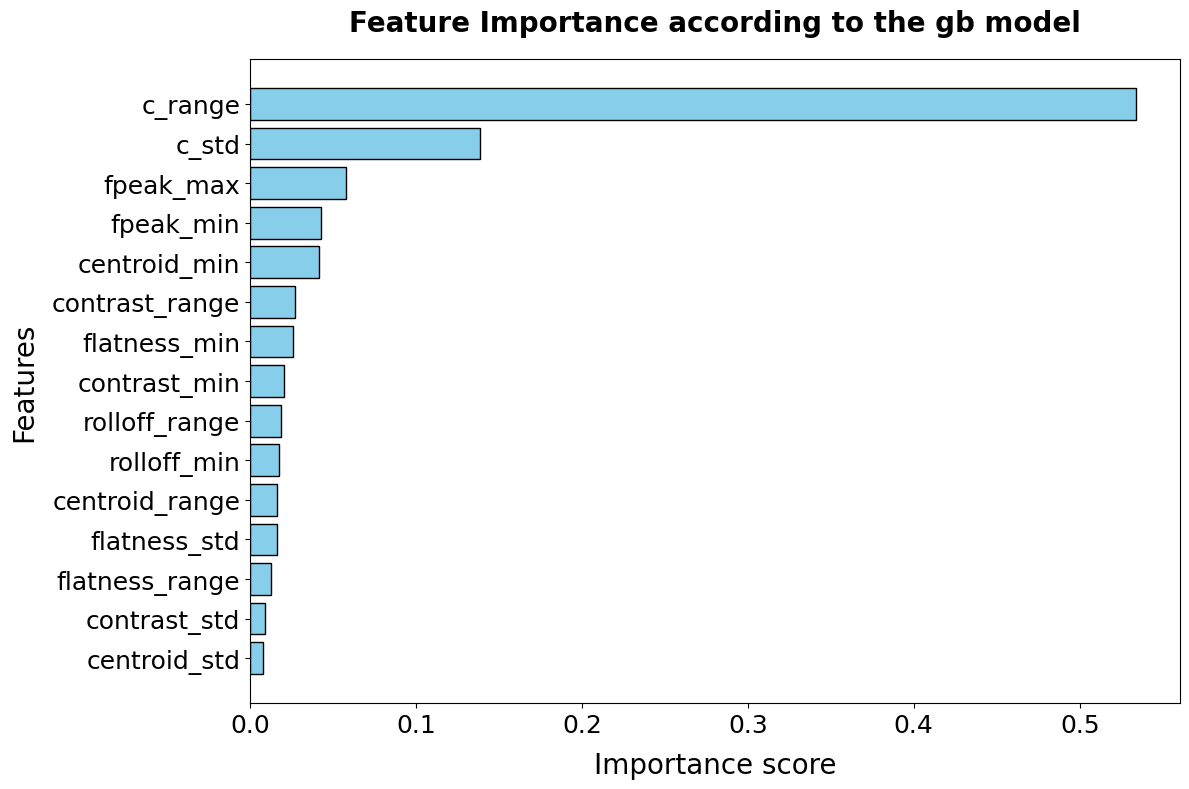

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure the AdaBoost model is trained on the ENTIRE dataset X
gb.fit(X, y)
#adaboost.fit(X, y)

# 2. Extract feature importances
#imp_adaboost = adaboost.feature_importances_
imp_gb = gb.feature_importances_

feat = X.columns

# 3. Create DataFrame (keeping all features with importance > 0)
df_importance = pd.DataFrame({
    'importance': imp_gb,
    'feature': feat
})

# Filtering (Optional: you can increase to > 0.005 if you have too many features)
df_importance = df_importance[df_importance['importance'] > 0.005]

# 4. Sort in descending order (crucial for readability)
df_importance = df_importance.sort_values(by='importance', ascending=False)

print("--- Feature Importance - gb ---")
print(df_importance)

# 5. Plotting (Tip: A HORIZONTAL bar chart is much easier to read)
plt.figure(figsize=(12, 8))  # Adjusted size for visual harmony

# Use barh (horizontal bars) so that feature names are readable from left to right
plt.barh(df_importance['feature'], df_importance['importance'], color='skyblue', edgecolor='black')

plt.gca().invert_yaxis()  # Keep the most important feature at the top

# Font size adjustments for scientific publication standards
plt.title("Feature Importance according to the gb model", fontsize=20, fontweight='bold', pad=20)
plt.xlabel("Importance score", fontsize=20, labelpad=10)
plt.ylabel("Features", fontsize=20, labelpad=10)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.tight_layout()  # Prevents feature names from being clipped at the edges
plt.show()

# 5. Correlations



In [ ]:
X_sub = df.drop(['sample_name',
'form',
 'rms_1',
 'rms_2',
 'rms_3',
 'rms_4',
 'rms_5',
 'rms_6',
 'rms_7',
 'rms_8',
 'rms_9',
 'flatness_1',
 'flatness_2',
 'flatness_3',
 'flatness_4',
 'flatness_5',
 'flatness_6',
 'flatness_7',
 'flatness_8',
 'flatness_9',
 'rolloff_1',
 'rolloff_2',
 'rolloff_3',
 'rolloff_4',
 'rolloff_5',
 'rolloff_6',
 'rolloff_7',
 'rolloff_8',
 'rolloff_9',
 'contrast_1',
 'contrast_2',
 'contrast_3',
 'contrast_4',
 'contrast_5',
 'contrast_6',
 'contrast_7',
 'contrast_8',
 'contrast_9',
 'fpeak_1',
 'fpeak_2',
 'fpeak_3',
 'fpeak_4',
 'fpeak_5',
 'fpeak_6',
 'fpeak_7',
 'fpeak_8',
 'fpeak_9',
 'c_1',
 'c_2',
 'c_3',
 'c_4',
 'c_5',
 'c_6',
 'c_7',
 'c_8',
 'c_9',
 'centroid_1',
 'centroid_2',
 'centroid_3',
 'centroid_4',
 'centroid_5',
 'centroid_6',
 'centroid_7',
 'centroid_8',
 'centroid_9'
                 ],axis=1)

In [ ]:
X_sub = X_sub.fillna(X_sub.mean())
X_sub = (X_sub-X_sub.min()) / (X_sub.max()-X_sub.min())

/tmp/ipykernel_2486/1164835777.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


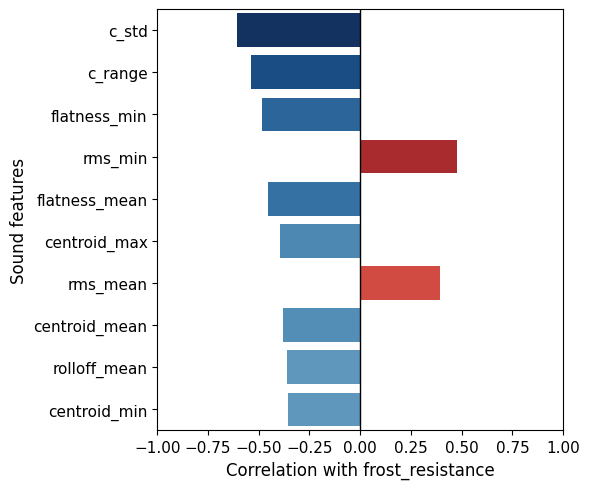

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

corr_frost = (
    X_sub.corr()['frost_resistance']
    .drop('frost_resistance')
    .sort_values(key=abs, ascending=False)
    .head(10)
)

# Normalisation sur les valeurs absolues
norm = mcolors.Normalize(vmin=0, vmax=np.abs(corr_frost).max())

colors = []
for x in corr_frost.values:
    if x >= 0:
        colors.append(cm.Reds(norm(abs(x))))   # Rouge de clair à foncé
    else:
        colors.append(cm.Blues(norm(abs(x))))  # Bleu de clair à foncé

plt.figure(figsize=(6, 5))

sns.barplot(
    x=corr_frost.values,
    y=corr_frost.index,
    palette=colors
)

plt.axvline(0, color='black', linewidth=1)
plt.xlabel("Correlation with frost_resistance", fontsize=12)
plt.ylabel("Sound features", fontsize=12)
plt.xlim(-1, 1)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()